# 04 - Modelagem

## Objetivo

Construir modelos capazes de identificar clientes com maior probabilidade de
não renovar sua apólice.

### Variável alvo

`Nao_Renovou`

- 1 → cliente não renovou
- 0 → cliente renovou

### Objetivo de negócio

Identificar clientes com maior risco de não renovação para apoiar ações
preventivas de retenção.

### Modelos avaliados

- Baseline;
- Regressão Logística;
- Random Forest;
- Gradient Boosting.

Como a base apresenta forte desbalanceamento entre as classes, a acurácia
não será utilizada como principal métrica de avaliação.

## 4.1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

## 4.2. Carregamento de dados

In [3]:
df = pd.read_excel(
    "../data/raw/base-seguros.xlsx",
    sheet_name="Base"
)

df.head()

,Flag_Renovou,Idade,Perfil_Risco,Diferenca_Perfil,Genero,Profissao,Tempo_Apolice,Uso_Veiculo,Qte_Apolices,Premio_Final,Premio_Qte_Parc,Premio_Pago_Ult,Premio_Mercado,Premio_Orig,Veic_Idade,Veic_Idade_Compra,Veic_Garagem,Veic_Potencia,Veic_Regiao
0,0,38,stable,only partner,Male,normal,1,private or freelance work,1,232.46,4 per year,232.47,221.56,243.59,9,8,private garage,225 kW,Reg7
1,1,35,stable,same,Male,normal,1,private or freelance work,1,208.53,4 per year,208.54,247.56,208.54,15,7,private garage,100 kW,Reg4
2,1,29,stable,same,Male,normal,0,private or freelance work,1,277.34,1 per year,277.35,293.32,277.35,14,6,underground garage,100 kW,Reg7
3,0,33,down,same,Female,medical,2,private or freelance work,1,239.51,4 per year,244.40,310.91,219.95,17,10,street,75 kW,Reg5
4,0,50,stable,same,Male,normal,8,unknown,1,554.54,4 per year,554.55,365.46,519.50,16,8,street,75 kW,Reg14


## 4.3. Criar variável alvo

In [4]:
df["Nao_Renovou"] = (
    df["Flag_Renovou"] == 0
).astype(int)

In [5]:
df["Nao_Renovou"].value_counts()

Nao_Renovou
1    20106
0     2954
Name: count, dtype: int64

In [6]:
print(
    "Taxa de não renovação:",
    df["Nao_Renovou"].mean()
)

print(
    "Taxa de renovação:",
    1 - df["Nao_Renovou"].mean()
)

Taxa de não renovação: 0.8718993928881179
Taxa de renovação: 0.1281006071118821


## 4.4. Separar X e y

In [7]:
X = df.drop(
    columns=[
        "Flag_Renovou",
        "Nao_Renovou"
    ]
)

y = df["Nao_Renovou"]

X.shape, y.shape

((23060, 18), (23060,))

## 4.5. Identificar variáveis categóricas e numéricas

In [8]:
variaveis_categoricas = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

variaveis_numericas = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [9]:
print("Categóricas:")
print(variaveis_categoricas)

print("\nNuméricas:")
print(variaveis_numericas)

Categóricas:
['Perfil_Risco', 'Diferenca_Perfil', 'Genero', 'Profissao', 'Uso_Veiculo', 'Premio_Qte_Parc', 'Veic_Garagem', 'Veic_Potencia', 'Veic_Regiao']

Numéricas:
['Idade', 'Tempo_Apolice', 'Qte_Apolices', 'Premio_Final', 'Premio_Pago_Ult', 'Premio_Mercado', 'Premio_Orig', 'Veic_Idade', 'Veic_Idade_Compra']


## 4.6. Pré-processamento

In [10]:
preprocessador = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            variaveis_numericas
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            variaveis_categoricas
        )
    ]
)

## 4.7. Separar treino, teste e validação

In [11]:
# Separar teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [12]:
# Separar validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

In [13]:
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (16141, 18)
Validação: (3460, 18)
Teste: (3459, 18)


## 4.8. Distribuição da variável target

In [14]:
def mostrar_distribuicao(y, nome):

    distribuicao = (
        y.value_counts()
        .sort_index()
        .to_frame("quantidade")
    )

    distribuicao["percentual"] = (
        distribuicao["quantidade"]
        / len(y)
        * 100
    )

    distribuicao.index = distribuicao.index.map({
        0: "Renovou",
        1: "Não renovou"
    })

    print(f"\n{nome}")
    display(distribuicao)

In [15]:
mostrar_distribuicao(y_train, "Treino")
mostrar_distribuicao(y_val, "Validação")
mostrar_distribuicao(y_test, "Teste")


Treino


,quantidade,percentual
Nao_Renovou,,
Renovou,2068,12.812093
Não renovou,14073,87.187907



Validação


,quantidade,percentual
Nao_Renovou,,
Renovou,443,12.803468
Não renovou,3017,87.196532



Teste


,quantidade,percentual
Nao_Renovou,,
Renovou,443,12.80717
Não renovou,3016,87.19283


## 4.9. Baseline

In [16]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(
    X_train,
    y_train
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.13,0.87]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](18,)","['Idade','Perfil_Risco','Diferenca_Perfil',...,'Veic_Garagem', 'Veic_Potencia','Veic_Regiao']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,18
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [17]:
baseline_pred_val = baseline.predict(X_val)

baseline_prob_val = baseline.predict_proba(X_val)[:, 1]

## 4.10 Função avaliação

In [18]:
def avaliar_modelo(
    nome,
    y_true,
    y_pred,
    y_prob
):

    return {
        "modelo": nome,
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_prob
        )
    }

## 4.11. Avaliar o Baseline

In [19]:
resultado_baseline = avaliar_modelo(
    "Baseline - Classe Majoritária",
    y_val,
    baseline_pred_val,
    baseline_prob_val
)

pd.DataFrame([resultado_baseline])

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline - Classe Majoritária,0.871965,0.871965,1.0,0.931604,0.5,0.871965


## 4.12. Modelagem

### Regressão Logística

In [20]:
modelo_logistico = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

### Random Forest

In [21]:
modelo_rf = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight=None
            )
        )
    ]
)

### Gradient Boosting

In [22]:
modelo_gb = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

## 4.13. Treinar os modelos

In [23]:
modelo_logistico.fit(
    X_train,
    y_train
)

modelo_rf.fit(
    X_train,
    y_train
)

modelo_gb.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Idade','Perfil_Risco','Diferenca_Perfil',...,'Veic_Garagem', 'Veic_Potencia','Veic_Regiao']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

## 4.14. Probabilidades na validação

In [24]:
prob_log_val = modelo_logistico.predict_proba(
    X_val
)[:, 1]

prob_rf_val = modelo_rf.predict_proba(
    X_val
)[:, 1]

prob_gb_val = modelo_gb.predict_proba(
    X_val
)[:, 1]

## 4.15. Predições usando threshold 0,50

In [25]:
pred_log_val = (
    prob_log_val >= 0.50
).astype(int)

pred_rf_val = (
    prob_rf_val >= 0.50
).astype(int)

pred_gb_val = (
    prob_gb_val >= 0.50
).astype(int)

## 4.16. Comparar todos os modelos

In [26]:
resultados_validacao = pd.DataFrame([

    resultado_baseline,

    avaliar_modelo(
        "Regressão Logística",
        y_val,
        pred_log_val,
        prob_log_val
    ),

    avaliar_modelo(
        "Random Forest",
        y_val,
        pred_rf_val,
        prob_rf_val
    ),

    avaliar_modelo(
        "Gradient Boosting",
        y_val,
        pred_gb_val,
        prob_gb_val
    )
])

In [27]:
resultados_validacao

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline - Classe Majoritária,0.871965,0.871965,1.000000,0.931604,0.500000,0.871965
1,Regressão Logística,0.871965,0.871965,1.000000,0.931604,0.614923,0.911628
2,Random Forest,0.871676,0.871928,0.999669,0.931439,0.594918,0.902415
3,Gradient Boosting,0.871965,0.871965,1.000000,0.931604,0.607603,0.907406


In [28]:
resultados_validacao.sort_values(
    "pr_auc",
    ascending=False
)

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Regressão Logística,0.871965,0.871965,1.000000,0.931604,0.614923,0.911628
3,Gradient Boosting,0.871965,0.871965,1.000000,0.931604,0.607603,0.907406
2,Random Forest,0.871676,0.871928,0.999669,0.931439,0.594918,0.902415
0,Baseline - Classe Majoritária,0.871965,0.871965,1.000000,0.931604,0.500000,0.871965


In [29]:
# ============================================================
# AVALIAÇÃO DOS MODELOS NO CONJUNTO DE TREINO
# ============================================================

prob_log_train = modelo_logistico.predict_proba(X_train)[:, 1]
prob_rf_train = modelo_rf.predict_proba(X_train)[:, 1]
prob_gb_train = modelo_gb.predict_proba(X_train)[:, 1]

pred_log_train = (prob_log_train >= 0.50).astype(int)
pred_rf_train = (prob_rf_train >= 0.50).astype(int)
pred_gb_train = (prob_gb_train >= 0.50).astype(int)


resultados_treino = pd.DataFrame([

    avaliar_modelo(
        "Regressão Logística",
        y_train,
        pred_log_train,
        prob_log_train
    ),

    avaliar_modelo(
        "Random Forest",
        y_train,
        pred_rf_train,
        prob_rf_train
    ),

    avaliar_modelo(
        "Gradient Boosting",
        y_train,
        pred_gb_train,
        prob_gb_train
    )
])

resultados_treino

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regressão Logística,0.871755,0.871863,0.999858,0.931484,0.646951,0.920287
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Gradient Boosting,0.872623,0.872620,0.999858,0.931916,0.718863,0.939670


In [30]:
comparacao = resultados_treino.merge(
    resultados_validacao[
        [
            "modelo",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc"
        ]
    ],
    on="modelo",
    suffixes=("_treino", "_validacao")
)

comparacao

,modelo,accuracy,precision_treino,recall_treino,f1_treino,roc_auc_treino,pr_auc_treino,precision_validacao,recall_validacao,f1_validacao,roc_auc_validacao,pr_auc_validacao
0,Regressão Logística,0.871755,0.871863,0.999858,0.931484,0.646951,0.920287,0.871965,1.000000,0.931604,0.614923,0.911628
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.871928,0.999669,0.931439,0.594918,0.902415
2,Gradient Boosting,0.872623,0.872620,0.999858,0.931916,0.718863,0.939670,0.871965,1.000000,0.931604,0.607603,0.907406


## 4.17. Análise dos thresholds

In [31]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

In [32]:
def analisar_thresholds(
    y_true,
    y_prob
):

    resultados = []

    for threshold in thresholds:

        y_pred = (
            y_prob >= threshold
        ).astype(int)

        resultados.append({
            "threshold": threshold,
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        })

    return pd.DataFrame(resultados)

## 4.18. Threshold da Regressão Logística

In [33]:
threshold_log = analisar_thresholds(
    y_val,
    prob_log_val
)

threshold_log

,threshold,precision,recall,f1
0,0.10,0.871965,1.000000,0.931604
1,0.15,0.871965,1.000000,0.931604
2,0.20,0.871965,1.000000,0.931604
3,0.25,0.871965,1.000000,0.931604
4,0.30,0.871965,1.000000,0.931604
5,0.35,0.871965,1.000000,0.931604
6,0.40,0.871965,1.000000,0.931604
7,0.45,0.871965,1.000000,0.931604
8,0.50,0.871965,1.000000,0.931604
9,0.55,0.871928,0.999669,0.931439


In [34]:
threshold_log.sort_values(
    "f1",
    ascending=False
)

,threshold,precision,recall,f1
0,0.10,0.871965,1.000000,0.931604
1,0.15,0.871965,1.000000,0.931604
2,0.20,0.871965,1.000000,0.931604
3,0.25,0.871965,1.000000,0.931604
4,0.30,0.871965,1.000000,0.931604
5,0.35,0.871965,1.000000,0.931604
6,0.40,0.871965,1.000000,0.931604
7,0.45,0.871965,1.000000,0.931604
8,0.50,0.871965,1.000000,0.931604
9,0.55,0.871928,0.999669,0.931439


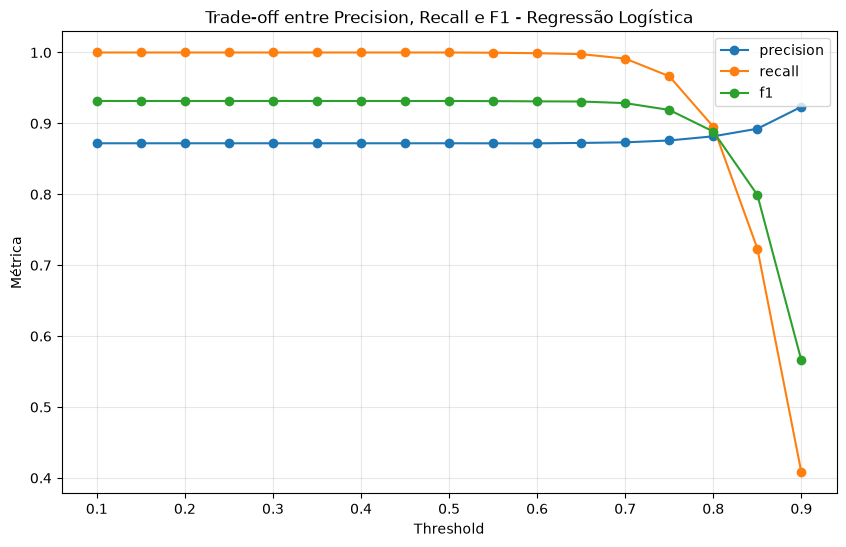

In [35]:
threshold_log.plot(
    x="threshold",
    y=["precision", "recall", "f1"],
    marker="o",
    figsize=(10, 6)
)

plt.title(
    "Trade-off entre Precision, Recall e F1 - Regressão Logística"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")

plt.grid(alpha=0.3)

plt.show()

In [36]:
threshold_negocio = 0.80

pred_risco = (
    prob_log_val >= threshold_negocio
).astype(int)

resultado_negocio = pd.DataFrame({
    "real": y_val,
    "probabilidade_risco": prob_log_val,
    "pred_risco": pred_risco
})

print(
    "Clientes na validação:",
    len(resultado_negocio)
)

print(
    "Clientes classificados como alto risco:",
    resultado_negocio["pred_risco"].sum()
)

print(
    "Percentual classificado como alto risco:",
    resultado_negocio["pred_risco"].mean()
)

Clientes na validação: 3460
Clientes classificados como alto risco: 3063
Percentual classificado como alto risco: 0.8852601156069364


In [37]:
total_clientes = len(y_val)

clientes_risco = (
    resultado_negocio["pred_risco"].sum()
)

clientes_nao_risco = (
    total_clientes - clientes_risco
)

print(f"Total de clientes: {total_clientes:,}")
print(f"Clientes classificados como risco: {clientes_risco:,}")
print(f"Clientes classificados como não risco: {clientes_nao_risco:,}")

print(
    f"Percentual da carteira classificada como risco: "
    f"{clientes_risco / total_clientes:.2%}"
)

Total de clientes: 3,460
Clientes classificados como risco: 3,063
Clientes classificados como não risco: 397
Percentual da carteira classificada como risco: 88.53%


In [38]:
thresholds_negocio = [
    0.80,
    0.85,
    0.90,
    0.95,
    0.97,
    0.98,
    0.99
]

resultados_negocio = []

for threshold in thresholds_negocio:

    pred = (prob_log_val >= threshold).astype(int)

    total = len(pred)
    clientes_risco = pred.sum()

    # Clientes reais que não renovaram
    total_nao_renovaram = (y_val == 0).sum()

    # Quantos não renovadores foram capturados
    nao_renovadores_capturados = (
        ((pred == 1) & (y_val == 0)).sum()
    )

    cobertura = (
        nao_renovadores_capturados /
        total_nao_renovaram
    )

    percentual_carteira = (
        clientes_risco / total
    )

    resultados_negocio.append({
        "threshold": threshold,
        "clientes_risco": clientes_risco,
        "percentual_carteira": percentual_carteira,
        "nao_renovadores_capturados": nao_renovadores_capturados,
        "cobertura_nao_renovadores": cobertura
    })

df_negocio = pd.DataFrame(resultados_negocio)

df_negocio

,threshold,clientes_risco,percentual_carteira,nao_renovadores_capturados,cobertura_nao_renovadores
0,0.80,3063,0.885260,362,0.817156
1,0.85,2446,0.706936,263,0.593679
2,0.90,1332,0.384971,102,0.230248
3,0.95,192,0.055491,14,0.031603
4,0.97,24,0.006936,1,0.002257
5,0.98,1,0.000289,0,0.000000
6,0.99,0,0.000000,0,0.000000


In [39]:
df_negocio["percentual_carteira"] = (
    df_negocio["percentual_carteira"] * 100
).round(2)

df_negocio["cobertura_nao_renovadores"] = (
    df_negocio["cobertura_nao_renovadores"] * 100
).round(2)

df_negocio

,threshold,clientes_risco,percentual_carteira,nao_renovadores_capturados,cobertura_nao_renovadores
0,0.80,3063,88.53,362,81.72
1,0.85,2446,70.69,263,59.37
2,0.90,1332,38.50,102,23.02
3,0.95,192,5.55,14,3.16
4,0.97,24,0.69,1,0.23
5,0.98,1,0.03,0,0.00
6,0.99,0,0.00,0,0.00


## 4.19. Threshold Random Forest

In [40]:
threshold_rf = analisar_thresholds(
    y_val,
    prob_rf_val
)

threshold_rf.sort_values(
    "f1",
    ascending=False
)

,threshold,precision,recall,f1
9,0.55,0.872433,0.999669,0.931727
0,0.10,0.871965,1.000000,0.931604
1,0.15,0.871965,1.000000,0.931604
3,0.25,0.871965,1.000000,0.931604
2,0.20,0.871965,1.000000,0.931604
5,0.35,0.871965,1.000000,0.931604
6,0.40,0.871965,1.000000,0.931604
4,0.30,0.871965,1.000000,0.931604
7,0.45,0.871928,0.999669,0.931439
8,0.50,0.871928,0.999669,0.931439


## 4.20. Threshold Gradient Boosting

In [41]:
threshold_gb = analisar_thresholds(
    y_val,
    prob_gb_val
)

threshold_gb.sort_values(
    "f1",
    ascending=False
)

,threshold,precision,recall,f1
0,0.10,0.871965,1.000000,0.931604
1,0.15,0.871965,1.000000,0.931604
2,0.20,0.871965,1.000000,0.931604
3,0.25,0.871965,1.000000,0.931604
4,0.30,0.871965,1.000000,0.931604
5,0.35,0.871965,1.000000,0.931604
6,0.40,0.871965,1.000000,0.931604
7,0.45,0.871965,1.000000,0.931604
8,0.50,0.871965,1.000000,0.931604
9,0.55,0.871928,0.999669,0.931439


## 4.21. Gráfico para comparar PR-AUC

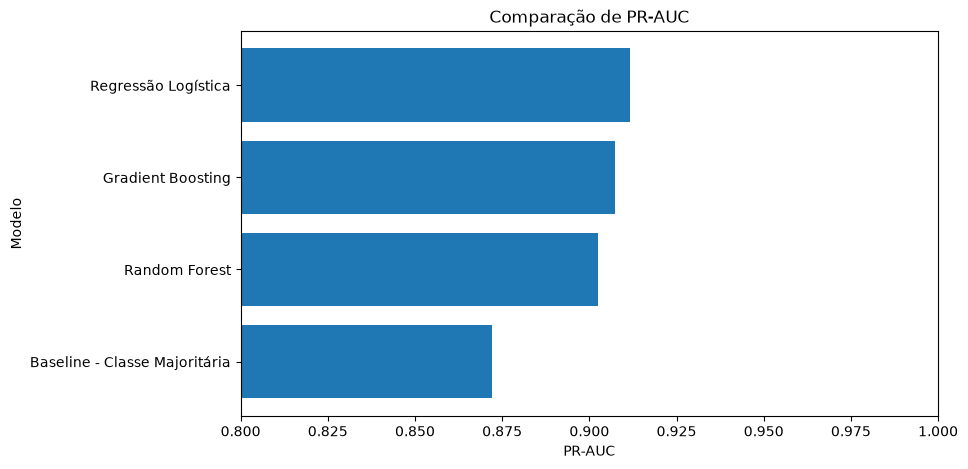

In [42]:
plt.figure(figsize=(9, 5))

ordenado = resultados_validacao.sort_values(
    "pr_auc",
    ascending=True
)

plt.barh(
    ordenado["modelo"],
    ordenado["pr_auc"]
)

plt.xlabel("PR-AUC")
plt.ylabel("Modelo")
plt.title("Comparação de PR-AUC")
plt.xlim(0.80, 1.00)

plt.show()

## 4.22. Matriz de confusão

In [43]:
def mostrar_matriz_confusao(
    nome,
    y_true,
    y_pred
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    print(nome)
    print(cm)

    print()

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Renovou",
                "Não renovou"
            ],
            zero_division=0
        )
    )

In [44]:
mostrar_matriz_confusao(
    "Baseline",
    y_val,
    baseline_pred_val
)

Baseline
[[   0  443]
 [   0 3017]]

              precision    recall  f1-score   support

     Renovou       0.00      0.00      0.00       443
 Não renovou       0.87      1.00      0.93      3017

    accuracy                           0.87      3460
   macro avg       0.44      0.50      0.47      3460
weighted avg       0.76      0.87      0.81      3460



In [45]:
mostrar_matriz_confusao(
    "Regressão Logística",
    y_val,
    pred_log_val
)

Regressão Logística
[[   0  443]
 [   0 3017]]

              precision    recall  f1-score   support

     Renovou       0.00      0.00      0.00       443
 Não renovou       0.87      1.00      0.93      3017

    accuracy                           0.87      3460
   macro avg       0.44      0.50      0.47      3460
weighted avg       0.76      0.87      0.81      3460



In [46]:
mostrar_matriz_confusao(
    "Random Forest",
    y_val,
    pred_rf_val
)

Random Forest
[[   0  443]
 [   1 3016]]

              precision    recall  f1-score   support

     Renovou       0.00      0.00      0.00       443
 Não renovou       0.87      1.00      0.93      3017

    accuracy                           0.87      3460
   macro avg       0.44      0.50      0.47      3460
weighted avg       0.76      0.87      0.81      3460



In [47]:
mostrar_matriz_confusao(
    "Gradient Boosting",
    y_val,
    pred_gb_val
)

Gradient Boosting
[[   0  443]
 [   0 3017]]

              precision    recall  f1-score   support

     Renovou       0.00      0.00      0.00       443
 Não renovou       0.87      1.00      0.93      3017

    accuracy                           0.87      3460
   macro avg       0.44      0.50      0.47      3460
weighted avg       0.76      0.87      0.81      3460



## 4.22. Seleção de Modelos

A seleção do modelo será realizada com base exclusivamente nos resultados
obtidos no conjunto de validação.

Os principais critérios considerados serão:

- PR-AUC: capacidade de identificar a classe positiva em um cenário
  desbalanceado;
- ROC-AUC: capacidade geral de discriminação;
- estabilidade entre treino e validação;
- ausência de overfitting excessivo;
- simplicidade e interpretabilidade.

O conjunto de teste não será utilizado nesta etapa.

In [48]:
# Ordena os modelos pela PR-AUC de validação
ranking_modelos = resultados_validacao.sort_values(
    by=["pr_auc", "roc_auc"],
    ascending=False
).reset_index(drop=True)

ranking_modelos

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regressão Logística,0.871965,0.871965,1.000000,0.931604,0.614923,0.911628
1,Gradient Boosting,0.871965,0.871965,1.000000,0.931604,0.607603,0.907406
2,Random Forest,0.871676,0.871928,0.999669,0.931439,0.594918,0.902415
3,Baseline - Classe Majoritária,0.871965,0.871965,1.000000,0.931604,0.500000,0.871965


In [49]:
modelo_escolhido = ranking_modelos.loc[0, "modelo"]

print(f"Modelo selecionado pela validação: {modelo_escolhido}")

Modelo selecionado pela validação: Regressão Logística


### Modelo selecionado

A Regressão Logística foi selecionada como modelo final.

Embora os modelos apresentem resultados semelhantes em métricas como
Recall e F1, essas métricas são fortemente influenciadas pelo desbalanceamento
da variável alvo.

A Regressão Logística apresentou:

- maior ROC-AUC na validação entre os modelos avaliados;
- maior PR-AUC na validação;
- comportamento mais estável entre treino e validação;
- menor evidência de overfitting;
- maior interpretabilidade em comparação com os modelos baseados em árvores.

O Random Forest foi descartado devido à forte diferença entre seu
desempenho no treinamento e na validação, indicando overfitting.

O Gradient Boosting também apresentou diferença entre treinamento e
validação, embora menos extrema que o Random Forest.

Portanto, a Regressão Logística será utilizada para a avaliação final
no conjunto de teste.

## 4.23. Avaliação final no conjunto de teste

In [52]:
# Probabilidades e previsões no conjunto de teste

pred_log_test = modelo_logistico.predict(X_test)

prob_log_test = modelo_logistico.predict_proba(
    X_test
)[:, 1]

## 4.24. Métricas finais

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

resultado_teste_log = pd.DataFrame([{
    "modelo": "Regressão Logística",
    "accuracy": accuracy_score(y_test, pred_log_test),
    "precision": precision_score(
        y_test,
        pred_log_test,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        pred_log_test,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        pred_log_test,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        prob_log_test
    ),
    "pr_auc": average_precision_score(
        y_test,
        prob_log_test
    )
}])

resultado_teste_log

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regressão Logística,0.871928,0.871928,1.0,0.931583,0.602582,0.905601


## 4.25. Comparar validação × teste

In [54]:
resultado_validacao_log = resultados_validacao[
    resultados_validacao["modelo"] == "Regressão Logística"
].copy()

resultado_comparacao_final = pd.DataFrame({
    "metrica": [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc"
    ],
    "validacao": [
        resultado_validacao_log["accuracy"].iloc[0],
        resultado_validacao_log["precision"].iloc[0],
        resultado_validacao_log["recall"].iloc[0],
        resultado_validacao_log["f1"].iloc[0],
        resultado_validacao_log["roc_auc"].iloc[0],
        resultado_validacao_log["pr_auc"].iloc[0]
    ],
    "teste": [
        resultado_teste_log["accuracy"].iloc[0],
        resultado_teste_log["precision"].iloc[0],
        resultado_teste_log["recall"].iloc[0],
        resultado_teste_log["f1"].iloc[0],
        resultado_teste_log["roc_auc"].iloc[0],
        resultado_teste_log["pr_auc"].iloc[0]
    ]
})

resultado_comparacao_final

,metrica,validacao,teste
0,accuracy,0.871965,0.871928
1,precision,0.871965,0.871928
2,recall,1.000000,1.000000
3,f1,0.931604,0.931583
4,roc_auc,0.614923,0.602582
5,pr_auc,0.911628,0.905601


## 4.26. Matriz de confusão final

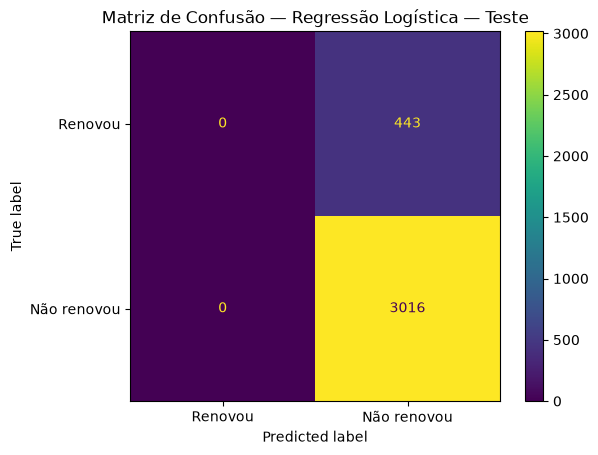

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_log_test,
    display_labels=[
        "Renovou",
        "Não renovou"
    ],
    values_format="d"
)

plt.title("Matriz de Confusão — Regressão Logística — Teste")
plt.show()

## 4.26. Relatório de classificação

In [56]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_log_test,
        target_names=[
            "Renovou",
            "Não renovou"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Renovou     0.0000    0.0000    0.0000       443
 Não renovou     0.8719    1.0000    0.9316      3016

    accuracy                         0.8719      3459
   macro avg     0.4360    0.5000    0.4658      3459
weighted avg     0.7603    0.8719    0.8123      3459



## 4.27. Avaliação do risco com threshold

In [57]:
threshold_final = 0.50

pred_risco_test = (
    prob_log_test >= threshold_final
).astype(int)

resultado_threshold_final = pd.DataFrame([{
    "threshold": threshold_final,
    "clientes_classificados_risco": pred_risco_test.sum(),
    "percentual_carteira_risco": pred_risco_test.mean(),
    "nao_renovadores_capturados": (
        (pred_risco_test == 1) &
        (y_test == 1)
    ).sum(),
    "total_nao_renovadores": (y_test == 1).sum()
}])

resultado_threshold_final

,threshold,clientes_classificados_risco,percentual_carteira_risco,nao_renovadores_capturados,total_nao_renovadores
0,0.5,3459,1.0,3016,3016


## 4.28. Cobertura dos não renovadores

In [58]:
cobertura_nao_renovadores = (
    ((pred_risco_test == 1) & (y_test == 1)).sum()
    / (y_test == 1).sum()
)

print(
    f"Cobertura dos não renovadores: "
    f"{cobertura_nao_renovadores:.2%}"
)

Cobertura dos não renovadores: 100.00%


## 4.29. Análise final de thresholds no teste

In [60]:
thresholds_teste = [0.50, 0.60, 0.70, 0.80]

resultados_threshold_teste = []

for threshold in thresholds_teste:

    pred = (
        prob_log_test >= threshold
    ).astype(int)

    clientes_risco = pred.sum()

    nao_renovadores_capturados = (
        (pred == 1) &
        (y_test == 1)
    ).sum()

    total_nao_renovadores = (
        y_test == 1
    ).sum()

    resultados_threshold_teste.append({
        "threshold": threshold,
        "clientes_risco": clientes_risco,
        "percentual_carteira_risco": (
            clientes_risco / len(y_test)
        ),
        "nao_renovadores_capturados": (
            nao_renovadores_capturados
        ),
        "cobertura_nao_renovadores": (
            nao_renovadores_capturados
            / total_nao_renovadores
        )
    })

resultados_threshold_teste = pd.DataFrame(
    resultados_threshold_teste
)

resultados_threshold_teste

,threshold,clientes_risco,percentual_carteira_risco,nao_renovadores_capturados,cobertura_nao_renovadores
0,0.5,3459,1.000000,3016,1.000000
1,0.6,3457,0.999422,3014,0.999337
2,0.7,3417,0.987858,2984,0.989390
3,0.8,3021,0.873374,2658,0.881300


## 4.30. Avaliação final no conjunto de teste

Após a seleção da Regressão Logística utilizando exclusivamente o
conjunto de validação, o modelo foi avaliado no conjunto de teste.

O conjunto de teste foi mantido separado durante as etapas anteriores
e utilizado somente para estimar o desempenho final do modelo.

A comparação entre validação e teste permite verificar a estabilidade
do modelo em dados não utilizados durante o desenvolvimento.

## 4.31. Conclusão da Modelagem

Foram avaliados três algoritmos de classificação:

- Regressão Logística;
- Random Forest;
- Gradient Boosting.

Também foi estabelecido um baseline utilizando a classe majoritária.

A comparação demonstrou que métricas como Accuracy, Recall e F1 devem
ser interpretadas com cautela devido ao forte desbalanceamento da variável
alvo, em que aproximadamente 87% dos clientes não renovaram suas apólices.

A Regressão Logística apresentou o melhor desempenho discriminativo entre
os modelos avaliados na validação, além de apresentar maior estabilidade
entre treinamento e validação.

O Random Forest apresentou forte evidência de overfitting, com desempenho
perfeito no treinamento e queda significativa no conjunto de validação.
Por esse motivo, não foi selecionado como modelo final.

O Gradient Boosting apresentou desempenho intermediário, porém também
apresentou diferença entre treinamento e validação.

Dessa forma, a Regressão Logística foi selecionada para a avaliação final
no conjunto de teste.

Apesar de apresentar desempenho superior ao baseline em ROC-AUC e PR-AUC,
o modelo possui capacidade discriminativa limitada. Portanto, seus
resultados devem ser utilizados como ferramenta de apoio à priorização
de clientes e não como decisão automática de retenção.

A análise de thresholds demonstra ainda que existe um trade-off entre
o tamanho da carteira de clientes classificados como risco e a cobertura
dos clientes que efetivamente não renovam.

Os resultados obtidos neste notebook serão utilizados no próximo estágio
do projeto para interpretar os fatores associados ao risco de não renovação
e propor ações de negócio para a SeguraAí.